# 02 – ML Validation (Baseline Reconstruction)

This notebook:
- Trains a regression model to predict the stable baseline segment from environmental variables
- Reports train/test RMSE on baseline-valid samples
- Predicts the missing baseline interval (`cablecal_baseline_ml_pred`) for downstream comparison

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

sys.path.append(os.path.abspath("../src"))

from mad_detection import reconstruct_cablecal
from pca_regression import validate_baseline_with_regression

## 1.1 KP-VLBA Station Analysis

In [2]:
data_path = "../data/raw/kp_vlba_2020-05-12.csv"
df_kp = pd.read_csv(data_path)

df_kp.head()

,time,cablecal,temp,pressure,humid
0,12-05-20 11:50:02,4.785224,14.234000,810.8,0.332793
1,12-05-20 11:52:05,4.750748,14.275000,810.8,0.325928
2,12-05-20 11:54:49,4.769335,14.270432,810.8,0.319564
3,12-05-20 11:57:43,4.746251,14.212625,810.8,0.315304
4,12-05-20 12:01:42,4.841585,14.266777,810.8,0.308423


In [3]:
df_kp = reconstruct_cablecal(df_kp)
df_kp.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean
0,2020-05-12 11:50:02,4.785224,14.234000,810.8,0.332793,4.785224,4.785224
1,2020-05-12 11:52:05,4.750748,14.275000,810.8,0.325928,4.750748,4.750748
2,2020-05-12 11:54:49,4.769335,14.270432,810.8,0.319564,4.769335,4.769335
3,2020-05-12 11:57:43,4.746251,14.212625,810.8,0.315304,4.746251,4.746251
4,2020-05-12 12:01:42,4.841585,14.266777,810.8,0.308423,4.841585,4.841585


In [4]:
df_kp[["time", "cablecal_baseline", 'temp', 'pressure', 'humid']].corr().map(lambda x: f"{x:.2f}")

,time,cablecal_baseline,temp,pressure,humid
time,1.00,-0.39,-0.54,-0.86,0.72
cablecal_baseline,-0.39,1.00,0.83,0.72,-0.19
temp,-0.54,0.83,1.00,0.67,-0.67
pressure,-0.86,0.72,0.67,1.00,-0.68
humid,0.72,-0.19,-0.67,-0.68,1.00


Exploratory Data Analysis
- Temperature, pressure, and humidity are used as predictors of the baseline cable calibration signal
- These environmental variables show moderate to strong correlation with the baseline signal and are also inter-correlated, indicating multicollinearity.

Model
- Linear regression is used as a transparent baseline model for validating the reconstruction workflow.
- To stabilize the regression model, PCA is applied before linear regression to decorrelate predictors while preserving variance.
- The trained model is applied to baseline-missing rows to generate  `cablecal_baseline_ml_pred`.

In [5]:
df_kp = validate_baseline_with_regression(df_kp)

Train RMSE: 0.10 cm | Test RMSE: 0.12 cm


Validation
- The true cable calibration signal is unknown.  
- The stable baseline segment (`cablecal_baseline`) is therefore treated as a reference interval to test whether environmental variables can explain the signal behavior.
- If the model achieves low error on baseline-valid samples, predictions over missing intervals provide an independent consistency check for the MAD-cleaned reconstruction.

In [6]:
df_kp.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean,cablecal_baseline_ml_pred
0,2020-05-12 11:50:02,4.785224,14.234000,810.8,0.332793,4.785224,4.785224,NaN
1,2020-05-12 11:52:05,4.750748,14.275000,810.8,0.325928,4.750748,4.750748,NaN
2,2020-05-12 11:54:49,4.769335,14.270432,810.8,0.319564,4.769335,4.769335,NaN
3,2020-05-12 11:57:43,4.746251,14.212625,810.8,0.315304,4.746251,4.746251,NaN
4,2020-05-12 12:01:42,4.841585,14.266777,810.8,0.308423,4.841585,4.841585,NaN


In [7]:
df_pred_segment_kp = df_kp[df_kp["cablecal_baseline_ml_pred"].notna()]
df_pred_segment_kp.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean,cablecal_baseline_ml_pred
157,2020-05-12 20:02:24,-11.306136,21.649834,811.900000,0.208926,NaN,5.786231,5.842455
158,2020-05-12 20:04:55,-11.280354,21.700000,811.900000,0.216010,NaN,5.812014,5.868707
159,2020-05-12 20:08:04,5.763447,21.700000,811.837000,0.209175,NaN,5.820608,5.855608
160,2020-05-12 20:09:54,-3.877878,21.700000,811.800333,0.205197,NaN,5.829202,5.847983
161,2020-05-12 20:12:48,-11.254571,21.814950,811.800000,0.202874,NaN,5.837796,5.863821


Rows containing ML baseline predictions are isolated for visualization, enabling direct comparison between the ML baseline estimate and the MAD-cleaned signal.

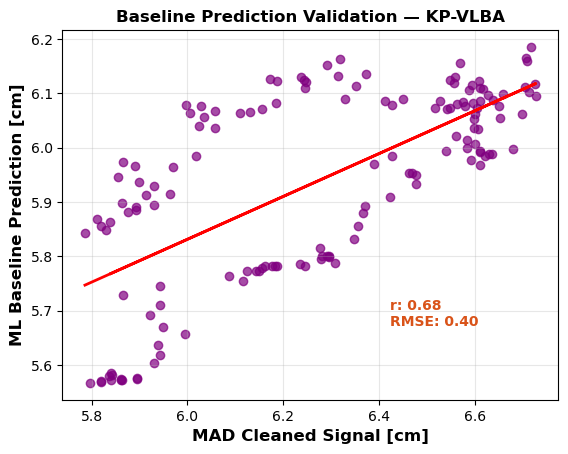

In [8]:
plt.scatter(df_pred_segment_kp["cablecal_clean"], df_pred_segment_kp["cablecal_baseline_ml_pred"], alpha=0.7, color = 'purple')

m, b = np.polyfit(df_pred_segment_kp["cablecal_clean"], df_pred_segment_kp["cablecal_baseline_ml_pred"], 1)
plt.plot(df_pred_segment_kp["cablecal_clean"], m * df_pred_segment_kp["cablecal_clean"] + b, 
         color='red', linewidth=2)

rmse_kp = root_mean_squared_error(df_pred_segment_kp["cablecal_clean"], df_pred_segment_kp["cablecal_baseline_ml_pred"])
r_kp = df_pred_segment_kp["cablecal_clean"].corr(df_pred_segment_kp["cablecal_baseline_ml_pred"])

plt.text(0.66, 0.2, f'r: {r_kp:.2f}\nRMSE: {rmse_kp:.2f}',
         transform=plt.gca().transAxes, fontsize=10,fontweight='bold', color='#D95319')

plt.xlabel('MAD Cleaned Signal [cm]', fontsize=12, fontweight='bold')
plt.ylabel('ML Baseline Prediction [cm]', fontsize=12, fontweight='bold')
plt.title('Baseline Prediction Validation — KP-VLBA', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='-', alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

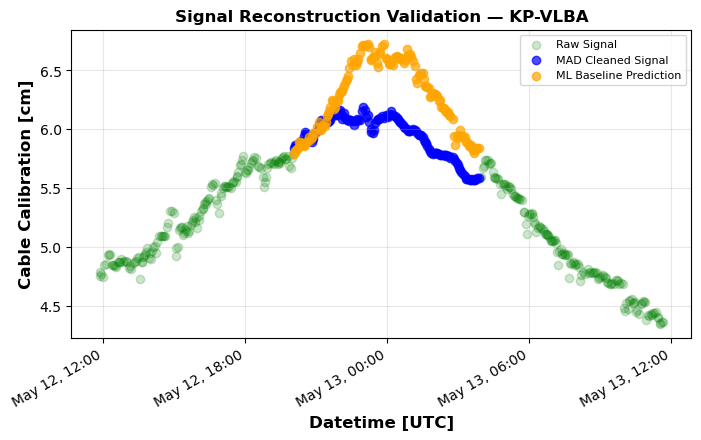

In [9]:
import matplotlib.dates as mdates
plt.figure(figsize=(8,4))  

plt.scatter(df_kp['time'], df_kp["cablecal_baseline"], alpha=0.2, label='Raw Signal', color='green') 
plt.scatter(df_pred_segment_kp['time'], df_pred_segment_kp["cablecal_baseline_ml_pred"], alpha=0.7, label='MAD Cleaned Signal', color='blue') 
plt.scatter(df_pred_segment_kp['time'], df_pred_segment_kp["cablecal_clean"], alpha=0.7, label='ML Baseline Prediction', color='orange') 

plt.xlabel('Datetime [UTC]', fontsize=12, fontweight='bold')
plt.ylabel('Cable Calibration [cm]', fontsize=12, fontweight='bold')
plt.title('Signal Reconstruction Validation — KP-VLBA', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %H:%M'))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[12, 18, 0, 6]))
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=10)

plt.legend()
plt.grid(True, linestyle='-', alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=8, loc="upper right")
plt.show()

## 1.2 OV-VLBA Station Analysis

In [10]:
data_path = "../data/raw/ov_vlba_2020-02-20.csv"
df_ov = pd.read_csv(data_path)

df_ov.head()

,time,cablecal,temp,pressure,humid
0,20-02-20 9:47:04,3.672474,0.465116,886.890698,0.378240
1,20-02-20 9:48:55,3.663180,0.344850,886.900000,0.370102
2,20-02-20 9:50:26,3.651488,0.284385,886.900000,0.357508
3,20-02-20 9:52:30,3.653287,0.201993,886.900000,0.340346
4,20-02-20 9:55:01,3.454225,0.298339,886.998339,0.352975


In [11]:
df_ov = reconstruct_cablecal(df_ov)
df_ov.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean
0,2020-02-20 09:47:04,3.672474,0.465116,886.890698,0.378240,3.672474,3.672474
1,2020-02-20 09:48:55,3.663180,0.344850,886.900000,0.370102,3.663180,3.663180
2,2020-02-20 09:50:26,3.651488,0.284385,886.900000,0.357508,3.651488,3.651488
3,2020-02-20 09:52:30,3.653287,0.201993,886.900000,0.340346,3.653287,3.653287
4,2020-02-20 09:55:01,3.454225,0.298339,886.998339,0.352975,3.454225,3.454225


In [12]:
df_ov[["time", "cablecal_baseline", 'temp', 'pressure', 'humid']].corr().map(lambda x: f"{x:.2f}")

,time,cablecal_baseline,temp,pressure,humid
time,1.00,0.67,0.49,-0.45,-0.51
cablecal_baseline,0.67,1.00,0.86,-0.37,-0.86
temp,0.49,0.86,1.00,-0.60,-0.98
pressure,-0.45,-0.37,-0.60,1.00,0.57
humid,-0.51,-0.86,-0.98,0.57,1.00


In [13]:
df_ov = validate_baseline_with_regression(df_ov)

Train RMSE: 0.11 cm | Test RMSE: 0.10 cm


In [14]:
df_ov.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean,cablecal_baseline_ml_pred
0,2020-02-20 09:47:04,3.672474,0.465116,886.890698,0.378240,3.672474,3.672474,NaN
1,2020-02-20 09:48:55,3.663180,0.344850,886.900000,0.370102,3.663180,3.663180,NaN
2,2020-02-20 09:50:26,3.651488,0.284385,886.900000,0.357508,3.651488,3.651488,NaN
3,2020-02-20 09:52:30,3.653287,0.201993,886.900000,0.340346,3.653287,3.653287,NaN
4,2020-02-20 09:55:01,3.454225,0.298339,886.998339,0.352975,3.454225,3.454225,NaN


In [15]:
df_pred_segment_ov = df_ov[df_ov["cablecal_baseline_ml_pred"].notna()]
df_pred_segment_ov.head()

,time,cablecal,temp,pressure,humid,cablecal_baseline,cablecal_clean,cablecal_baseline_ml_pred
307,2020-02-20 20:09:51,-5.788077,15.302990,887.301993,0.150984,NaN,4.388378,4.480153
308,2020-02-20 20:13:21,-5.824052,15.231229,887.300000,0.151669,NaN,4.424353,4.476600
309,2020-02-20 20:14:26,-5.840540,15.209635,887.300000,0.151879,NaN,4.440842,4.475436
310,2020-02-20 20:15:48,-5.834245,15.235216,887.282392,0.151631,NaN,4.434546,4.479638
311,2020-02-20 20:17:15,-5.840840,15.293023,887.253488,0.151072,NaN,4.441142,4.487389


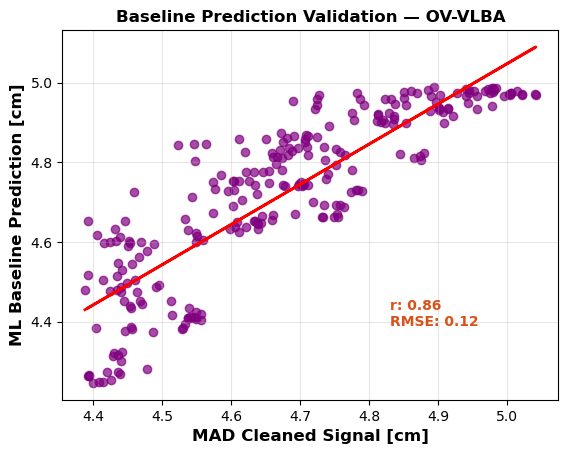

In [16]:
plt.scatter(df_pred_segment_ov["cablecal_clean"], df_pred_segment_ov["cablecal_baseline_ml_pred"], alpha=0.7, color = 'purple')

m, b = np.polyfit(df_pred_segment_ov["cablecal_clean"], df_pred_segment_ov["cablecal_baseline_ml_pred"], 1)
plt.plot(df_pred_segment_ov["cablecal_clean"], m * df_pred_segment_ov["cablecal_clean"] + b, 
         color='red', linewidth=2)

rmse_ov = root_mean_squared_error(df_pred_segment_ov["cablecal_clean"], df_pred_segment_ov["cablecal_baseline_ml_pred"])
r_ov = df_pred_segment_ov["cablecal_clean"].corr(df_pred_segment_ov["cablecal_baseline_ml_pred"])

plt.text(0.66, 0.2, f'r: {r_ov:.2f}\nRMSE: {rmse_ov:.2f}',
         transform=plt.gca().transAxes, fontsize=10,fontweight='bold', color='#D95319')

plt.xlabel('MAD Cleaned Signal [cm]', fontsize=12, fontweight='bold')
plt.ylabel('ML Baseline Prediction [cm]', fontsize=12, fontweight='bold')
plt.title('Baseline Prediction Validation — OV-VLBA', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='-', alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

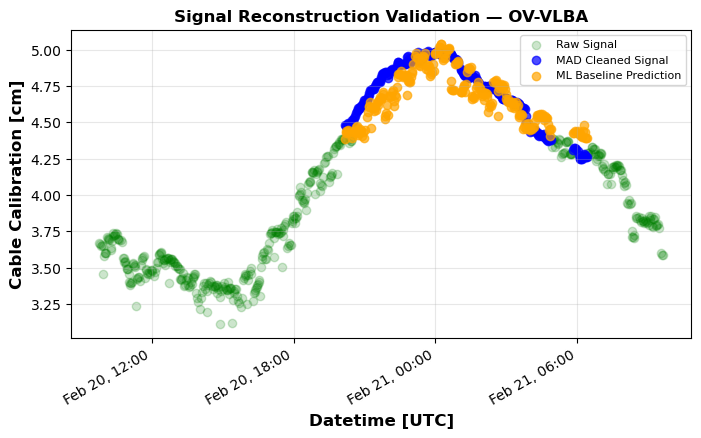

In [17]:
import matplotlib.dates as mdates
plt.figure(figsize=(8,4))  

plt.scatter(df_ov['time'], df_ov["cablecal_baseline"], alpha=0.2, label='Raw Signal', color='green') 
plt.scatter(df_pred_segment_ov['time'], df_pred_segment_ov["cablecal_baseline_ml_pred"], alpha=0.7, label='MAD Cleaned Signal', color='blue') 
plt.scatter(df_pred_segment_ov['time'], df_pred_segment_ov["cablecal_clean"], alpha=0.7, label='ML Baseline Prediction', color='orange') 

plt.xlabel('Datetime [UTC]', fontsize=12, fontweight='bold')
plt.ylabel('Cable Calibration [cm]', fontsize=12, fontweight='bold')
plt.title('Signal Reconstruction Validation — OV-VLBA', fontsize=12, fontweight='bold')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %H:%M'))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))  
plt.gca().xaxis.set_major_locator(mdates.HourLocator(byhour=[12, 18, 0, 6]))
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=10)

plt.grid(True, linestyle='-', alpha=0.3)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=8, loc="upper right")
plt.show()

## 1.3 Cross-Station Summary

In [18]:
# KP correlations
rct_kp, rcp_kp, rch_kp = [df_kp["cablecal_clean"].corr(df_kp[c]) for c in ["temp","pressure","humid"]]
rpt_kp, rpp_kp, rph_kp = [df_kp["cablecal_baseline_ml_pred"].corr(df_kp[c]) for c in ["temp","pressure","humid"]]

# OV correlations
rct_ov, rcp_ov, rch_ov = [df_ov["cablecal_clean"].corr(df_ov[c]) for c in ["temp","pressure","humid"]]
rpt_ov, rpp_ov, rph_ov = [df_ov["cablecal_baseline_ml_pred"].corr(df_ov[c]) for c in ["temp","pressure","humid"]]

summary_df = pd.DataFrame({
    ("Station",""): ["KP-VLBA","OV-VLBA"],
    ("Signal RMSE [cm]","clean vs pred"): [rmse_kp, rmse_ov],
    ("Signal r ","clean vs pred"): [r_kp, r_ov],

    ("r (Temp)","clean"): [rct_kp, rct_ov],
    ("r (Temp)","pred"):  [rpt_kp, rpt_ov],

    ("r (Pressure)","clean"): [rcp_kp, rcp_ov],
    ("r (Pressure)","pred"):  [rpp_kp, rpp_ov],

    ("r (Humidity)","clean"): [rch_kp, rch_ov],
    ("r (Humidity)","pred"):  [rph_kp, rph_ov],
})

summary_df = summary_df.round(2)
summary_df

Station Signal RMSE [cm]     Signal r  r (Temp)      r (Pressure)        \
              clean vs pred clean vs pred    clean pred        clean  pred   
0  KP-VLBA             0.40          0.68     0.84  0.9         0.27  0.36   
1  OV-VLBA             0.12          0.86     0.93  0.9        -0.81 -0.91   

  r (Humidity)        
         clean  pred  
0        -0.24 -0.77  
1        -0.91 -0.88

Millimeter-level RMSE indicates that the baseline segment of the cable-calibration signal is largely predictable from environmental variables (temperature, pressure, humidity). This supports using `cablecal_baseline_ml_pred` as an independent reference when evaluating the MAD-cleaned reconstruction.

The ML baseline captures the environmental response of the signal, while MAD-based cleaning removes step discontinuities in the raw time series. The strong agreement between the cleaned signal and the ML prediction indicates that the reconstructed cable-calibration series preserves the underlying environmental structure.